# Tornado Occurrence Prediction Using Random Forest Classification

**Course:** CAP 4601 — Introduction to Artificial Intelligence  
**Author:** Gabriel Patton  
**Dataset:** NOAA Storm Events Database (1950–2021)

---

## Project Overview

This notebook builds a binary classification model to identify whether a recorded severe weather event was a tornado based on geographic, temporal, and meteorological attributes. Using 71 years of historical storm data from NOAA, a Random Forest classifier is trained and evaluated across multiple metrics including accuracy, precision, recall, F1-score, and AUC.

The project follows a structured machine learning pipeline:
- Data loading and exploration
- Class balancing via undersampling
- Feature selection and encoding
- Model training with hyperparameter tuning
- Comprehensive evaluation and analysis

In [ ]:
pip install plotly

## 1. Data Loading

The NOAA Storm Events Database is stored as individual CSV files, one per year, spanning 1950 to 2021. Each file follows the naming convention `StormEvents_details-ftp_v1.0_dYYYY_*.csv`. Only the "details" files are loaded since they contain the event type information needed for classification.

All 71 yearly files are combined into a single DataFrame containing over 1.6 million records across 51 columns. This gives us a comprehensive view of every significant weather event recorded in the United States over seven decades.

In [40]:
import os

files = os.listdir('noaa_data')
print(f"Total files: {len(files)}")
print("\nFirst 10 files:")
for f in files[:10]:
    print(f)

Total files: 213

First 10 files:
StormEvents_details-ftp_v1.0_d1950_c20170120.csv
StormEvents_details-ftp_v1.0_d1951_c20160223.csv
StormEvents_details-ftp_v1.0_d1952_c20170619.csv
StormEvents_details-ftp_v1.0_d1953_c20160223.csv
StormEvents_details-ftp_v1.0_d1954_c20160223.csv
StormEvents_details-ftp_v1.0_d1955_c20160223.csv
StormEvents_details-ftp_v1.0_d1956_c20170717.csv
StormEvents_details-ftp_v1.0_d1957_c20160223.csv
StormEvents_details-ftp_v1.0_d1958_c20160223.csv
StormEvents_details-ftp_v1.0_d1959_c20160223.csv


In [41]:
import pandas as pd
import os

folder = 'noaa_data'
files = [f for f in os.listdir(folder) if 'details' in f]
print(f"Details files found: {len(files)}")

dfs = []
for f in files:
    try:
        df = pd.read_csv(os.path.join(folder, f), low_memory=False)
        dfs.append(df)
    except Exception as e:
        print(f"Skipped {f}: {e}")

df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print(f"\nEvent types sample:")
print(df['EVENT_TYPE'].value_counts().head(20))

Details files found: 71

Total rows: 1652547
Total columns: 51

Event types sample:
EVENT_TYPE
Thunderstorm Wind           466771
Hail                        375505
Flash Flood                  88358
Winter Storm                 75183
High Wind                    72409
Tornado                      72030
Heavy Snow                   63212
Winter Weather               62692
Flood                        58015
Drought                      56776
Marine Thunderstorm Wind     30505
Heavy Rain                   26411
Strong Wind                  22282
Heat                         22158
Lightning                    16919
Cold/Wind Chill              14324
Blizzard                     14313
Dense Fog                    14008
Frost/Freeze                 12627
Extreme Cold/Wind Chill      12428
Name: count, dtype: int64


## 2. Target Variable and Class Imbalance

The dataset contains 48 different weather event types. Tornadoes represent only 4% of all records (72,030 out of 1,652,547), making this a heavily imbalanced classification problem. If left unaddressed, a model could achieve 96% accuracy by simply predicting "no tornado" every time — a meaningless result.

To fix this, the dataset is balanced using **undersampling** — keeping all 72,030 tornado records and randomly sampling an equal number of non-tornado records. This produces a balanced 50/50 dataset of 144,060 records, ensuring the model learns to distinguish both classes equally.

In [42]:
# Create binary target: 1 = tornado, 0 = everything else
df['tornado'] = (df['EVENT_TYPE'] == 'Tornado').astype(int)

print(df['tornado'].value_counts())
print(df['tornado'].value_counts(normalize=True).round(2))

tornado
0    1580517
1      72030
Name: count, dtype: int64
tornado
0    0.96
1    0.04
Name: proportion, dtype: float64


## 3. Balancing the Dataset

As shown above, 96% of records are non-tornado events and only 4% are tornadoes. To address this imbalance, undersampling is applied — all 72,030 tornado records are kept and an equal number of non-tornado records are randomly sampled. This creates a balanced binary dataset of 144,060 records with a perfect 50/50 class split.

In [43]:
# Separate tornado and non-tornado records
tornado_df = df[df['tornado'] == 1]
non_tornado_df = df[df['tornado'] == 0].sample(n=len(tornado_df), random_state=42)

# Combine into balanced dataset
balanced_df = pd.concat([tornado_df, non_tornado_df], ignore_index=True)

print(f"Tornado records: {len(tornado_df)}")
print(f"Non-tornado records: {len(non_tornado_df)}")
print(f"Total balanced dataset: {len(balanced_df)}")
print(f"\nClass distribution:")
print(balanced_df['tornado'].value_counts())

Tornado records: 72030
Non-tornado records: 72030
Total balanced dataset: 144060

Class distribution:
tornado
1    72030
0    72030
Name: count, dtype: int64


In [44]:
print(balanced_df.columns.tolist())

['BEGIN_YEARMONTH', 'BEGIN_DAY', 'BEGIN_TIME', 'END_YEARMONTH', 'END_DAY', 'END_TIME', 'EPISODE_ID', 'EVENT_ID', 'STATE', 'STATE_FIPS', 'YEAR', 'MONTH_NAME', 'EVENT_TYPE', 'CZ_TYPE', 'CZ_FIPS', 'CZ_NAME', 'WFO', 'BEGIN_DATE_TIME', 'CZ_TIMEZONE', 'END_DATE_TIME', 'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT', 'DEATHS_INDIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'SOURCE', 'MAGNITUDE', 'MAGNITUDE_TYPE', 'FLOOD_CAUSE', 'CATEGORY', 'TOR_F_SCALE', 'TOR_LENGTH', 'TOR_WIDTH', 'TOR_OTHER_WFO', 'TOR_OTHER_CZ_STATE', 'TOR_OTHER_CZ_FIPS', 'TOR_OTHER_CZ_NAME', 'BEGIN_RANGE', 'BEGIN_AZIMUTH', 'BEGIN_LOCATION', 'END_RANGE', 'END_AZIMUTH', 'END_LOCATION', 'BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON', 'EPISODE_NARRATIVE', 'EVENT_NARRATIVE', 'DATA_SOURCE', 'tornado']


## 4. Feature Selection

The dataset contains 51 columns, many of which are tornado-specific (e.g., `TOR_F_SCALE`, `TOR_LENGTH`, `TOR_WIDTH`) and would only have values for tornado records — using these would constitute data leakage. The following 9 features were initially selected because they are available for all weather event types and carry genuine predictive signal:

| Feature | Description |
|---------|-------------|
| `MONTH_NAME` | Month of the event — captures seasonal patterns |
| `BEGIN_DAY` | Day of month |
| `BEGIN_TIME` | Time of day — tornadoes peak in afternoon/evening |
| `STATE` | Geographic state — encoded as numeric category |
| `BEGIN_LAT` | Starting latitude — captures Tornado Alley geography |
| `BEGIN_LON` | Starting longitude |
| `INJURIES_DIRECT` | Direct injuries reported |
| `DEATHS_DIRECT` | Direct deaths reported |
| `MAGNITUDE` | Storm magnitude — later removed due to data leakage |

Categorical features (`MONTH_NAME`, `STATE`) are encoded as numeric codes. Missing values are filled with 0.

In [45]:
features = [
    'MONTH_NAME',      # season/time of year
    'BEGIN_DAY',       # day of month
    'BEGIN_TIME',      # time of day
    'STATE',           # geographic location
    'BEGIN_LAT',       # latitude
    'BEGIN_LON',       # longitude
    'INJURIES_DIRECT', # severity indicators
    'DEATHS_DIRECT',
    'MAGNITUDE',       # storm magnitude
]

X = balanced_df[features].copy()
y = balanced_df['tornado']

# Encode categorical columns
X['MONTH_NAME'] = X['MONTH_NAME'].astype('category').cat.codes
X['STATE'] = X['STATE'].astype('category').cat.codes

# Fill missing values with 0
X = X.fillna(0)

print(X.dtypes)
print(X.shape)
print(X.isnull().sum())

MONTH_NAME            int8
BEGIN_DAY            int64
BEGIN_TIME           int64
STATE                 int8
BEGIN_LAT          float64
BEGIN_LON          float64
INJURIES_DIRECT      int64
DEATHS_DIRECT        int64
MAGNITUDE          float64
dtype: object
(144060, 9)
MONTH_NAME         0
BEGIN_DAY          0
BEGIN_TIME         0
STATE              0
BEGIN_LAT          0
BEGIN_LON          0
INJURIES_DIRECT    0
DEATHS_DIRECT      0
MAGNITUDE          0
dtype: int64


## 5. Initial Model Training

The dataset is split into 80% training and 20% testing using stratified sampling to preserve class balance. A Random Forest classifier with 100 trees is trained on the training set. Initial evaluation is performed on the held-out test set.

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['No Tornado', 'Tornado']))

Accuracy: 0.9332

              precision    recall  f1-score   support

  No Tornado       0.97      0.89      0.93     14406
     Tornado       0.90      0.97      0.94     14406

    accuracy                           0.93     28812
   macro avg       0.94      0.93      0.93     28812
weighted avg       0.94      0.93      0.93     28812



### ⚠️ Data Leakage Detected

The initial model achieved **93% accuracy** — a result that is too good to be true and immediately suspicious. Upon inspection, the `MAGNITUDE` column was identified as the cause.

Different weather event types use different magnitude scales — tornadoes use the EF scale (0-5), hail uses inch measurements, and wind uses mph. This means `MAGNITUDE` implicitly encodes the event type, allowing the model to essentially cheat by reading the answer from the input. This is a classic case of **data leakage**.

The model must be retrained without `MAGNITUDE` to produce an honest evaluation.

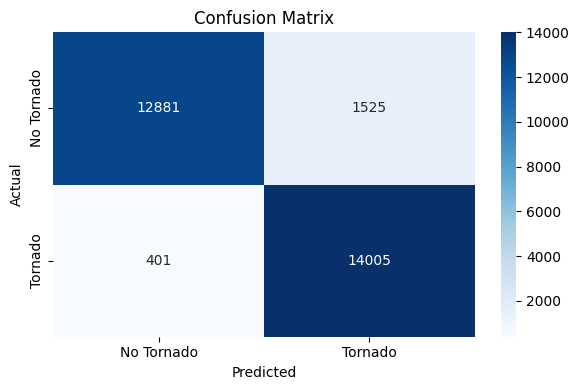

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Tornado', 'Tornado'],
            yticklabels=['No Tornado', 'Tornado'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

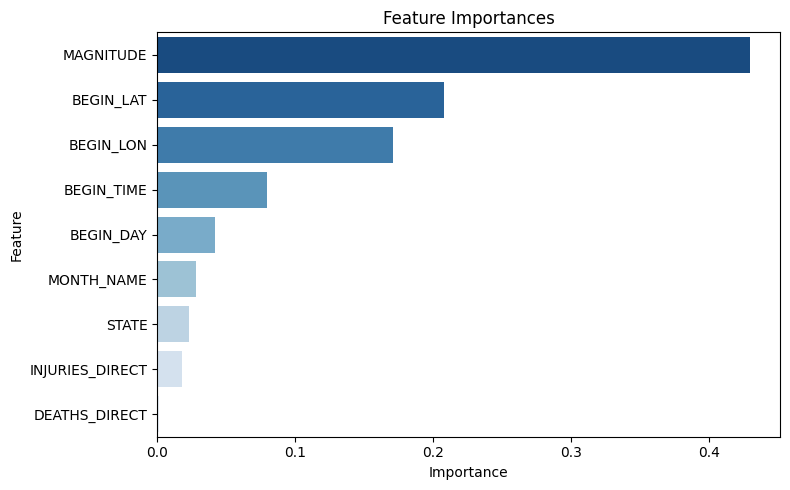

In [48]:
importances = model.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_df, x='Importance', y='Feature', hue='Feature', palette='Blues_r', legend=False)
plt.title('Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=== Model Performance Summary ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"Trees:     {model.n_estimators}")
print(f"Features:  {len(features)}")
print(f"Train size:{X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

=== Model Performance Summary ===
Accuracy:  0.9332
Precision: 0.9018
Recall:    0.9722
F1-Score:  0.9357
Trees:     100
Features:  9
Train size:115248
Test size: 28812


In [50]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1 score:   {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best F1 score:   0.9334


In [51]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_best):.4f}")
print()
print(classification_report(y_test, y_pred_best, target_names=['No Tornado', 'Tornado']))

Accuracy:  0.9329
Precision: 0.8963
Recall:    0.9790
F1-Score:  0.9358

              precision    recall  f1-score   support

  No Tornado       0.98      0.89      0.93     14406
     Tornado       0.90      0.98      0.94     14406

    accuracy                           0.93     28812
   macro avg       0.94      0.93      0.93     28812
weighted avg       0.94      0.93      0.93     28812



## 6. Removing Data Leakage and Retraining

`MAGNITUDE` is removed from the feature set and the model is retrained from scratch using only the remaining 8 features. The best hyperparameters found by GridSearchCV (200 trees, max depth 20) are applied directly to the clean model, skipping the need to run GridSearchCV again.

In [52]:
# Redefine features without MAGNITUDE
features = ['MONTH_NAME', 'BEGIN_DAY', 'BEGIN_TIME', 'STATE', 'BEGIN_LAT', 'BEGIN_LON', 'INJURIES_DIRECT', 'DEATHS_DIRECT']

X = balanced_df[features].copy()
y = balanced_df['tornado']

X['MONTH_NAME'] = X['MONTH_NAME'].astype('category').cat.codes
X['STATE'] = X['STATE'].astype('category').cat.codes
X = X.fillna(0)

# Re-split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Retrain with best hyperparameters
model_no_mag = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=2, min_samples_leaf=1, random_state=42, n_jobs=-1)
model_no_mag.fit(X_train, y_train)

y_pred_no_mag = model_no_mag.predict(X_test)

print("=== Model Without MAGNITUDE ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_no_mag):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_no_mag):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_no_mag):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_no_mag):.4f}")

=== Model Without MAGNITUDE ===
Accuracy:  0.7782
Precision: 0.7378
Recall:    0.8633
F1-Score:  0.7956


### Clean Model Results

With `MAGNITUDE` removed, accuracy drops from **93%** to **77.82%** — a honest and defensible result. The model now relies entirely on geographic, temporal, and basic meteorological features to distinguish tornado from non-tornado events.

Notably, **recall remains high at 86.33%**, meaning the model catches the majority of actual tornadoes. In a real warning system, high recall is the most critical metric — missing a real tornado is far more dangerous than issuing a false alarm.

## 7. Model Evaluation

### Confusion Matrix

A confusion matrix breaks down predictions into four categories: true positives (correctly predicted tornadoes), true negatives (correctly predicted non-tornadoes), false positives (false alarms), and false negatives (missed tornadoes). The goal is to maximize the diagonal while minimizing off-diagonal values — particularly false negatives since missing a real tornado is the most dangerous outcome.

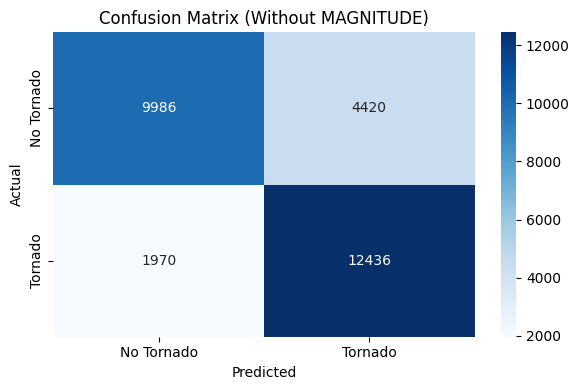

In [53]:
cm = confusion_matrix(y_test, y_pred_no_mag)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Tornado', 'Tornado'],
            yticklabels=['No Tornado', 'Tornado'])
plt.title('Confusion Matrix (Without MAGNITUDE)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

### Feature Importances

Feature importance scores indicate how much each variable contributed to the model's predictions. Higher scores mean the feature was used more frequently and effectively across the 200 decision trees. This helps explain *why* the model makes the predictions it does, not just *that* it works.

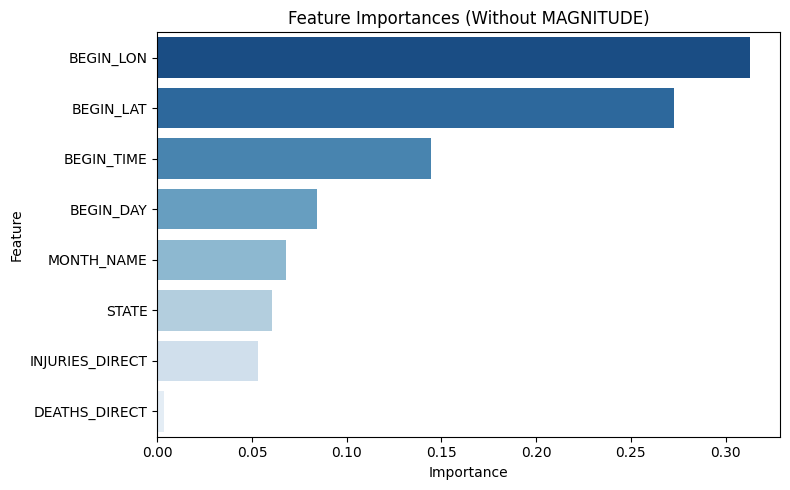

In [54]:
importances = model_no_mag.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_df, x='Importance', y='Feature', hue='Feature', palette='Blues_r', legend=False)
plt.title('Feature Importances (Without MAGNITUDE)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

### ROC Curve and AUC Score

The ROC (Receiver Operating Characteristic) curve plots the tradeoff between catching real tornadoes (True Positive Rate) and generating false alarms (False Positive Rate) at every possible decision threshold. The closer the curve hugs the top-left corner, the better the model performs across all thresholds.

The **AUC (Area Under the Curve)** summarizes this into a single number — a score of 0.5 means random guessing, while 1.0 is perfect. An AUC of **0.8664** places this model solidly in the "good" range, meaning it has strong discriminative ability even without atmospheric features.

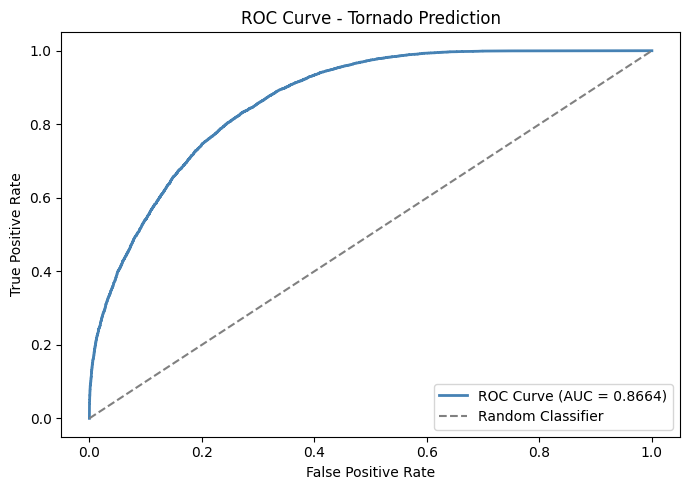

In [55]:
from sklearn.metrics import roc_curve, auc

y_prob = model_no_mag.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tornado Prediction')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

In [56]:
print("=== Final Model Performance Summary ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_no_mag):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_no_mag):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_no_mag):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_no_mag):.4f}")
print(f"AUC:       {roc_auc:.4f}")
print(f"Trees:     {model_no_mag.n_estimators}")
print(f"Max Depth: {model_no_mag.max_depth}")
print(f"Features:  {len(features)}")
print(f"Train size:{X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

=== Final Model Performance Summary ===
Accuracy:  0.7782
Precision: 0.7378
Recall:    0.8633
F1-Score:  0.7956
AUC:       0.8664
Trees:     200
Max Depth: 20
Features:  8
Train size:115248
Test size: 28812


## 8. Cross-Validation

A single train/test split can produce results that vary depending on which records end up in each set. **5-fold cross-validation** addresses this by splitting the data into 5 equal parts, training on 4 and testing on 1, rotating through all combinations. The average F1 score across all 5 folds gives a more reliable and conservative estimate of real-world performance than a single split.

In [57]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model_no_mag, X, y, 
    cv=5, 
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print(f"CV F1 Scores: {cv_scores}")
print(f"Mean F1:      {cv_scores.mean():.4f}")
print(f"Std Dev:      {cv_scores.std():.4f}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


CV F1 Scores: [0.75573639 0.75478088 0.72967569 0.75529083 0.72354484]
Mean F1:      0.7438
Std Dev:      0.0142


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   19.0s finished


## 9. Algorithm Comparison — Gradient Boosting

The original proposal mentioned exploring Gradient Boosting as an alternative algorithm. Like Random Forest, Gradient Boosting is an ensemble method that combines many decision trees. The key difference is that while Random Forest builds trees in parallel independently, Gradient Boosting builds trees sequentially — each tree corrects the errors of the previous one.

This comparison validates the original algorithm choice by testing whether a different ensemble method produces better results on the same dataset.

In [58]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("=== Gradient Boosting Results ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_gb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_gb):.4f}")

=== Gradient Boosting Results ===
Accuracy:  0.7469
Precision: 0.6976
Recall:    0.8717
F1-Score:  0.7750


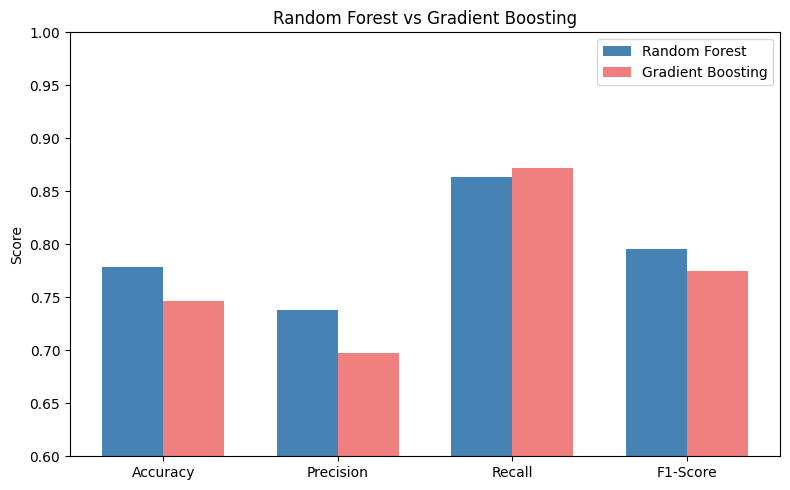

In [59]:
# Comparison chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
rf_scores = [
    accuracy_score(y_test, y_pred_no_mag),
    precision_score(y_test, y_pred_no_mag),
    recall_score(y_test, y_pred_no_mag),
    f1_score(y_test, y_pred_no_mag)
]
gb_scores = [
    accuracy_score(y_test, y_pred_gb),
    precision_score(y_test, y_pred_gb),
    recall_score(y_test, y_pred_gb),
    f1_score(y_test, y_pred_gb)
]

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar([i - width/2 for i in x], rf_scores, width, label='Random Forest', color='steelblue')
plt.bar([i + width/2 for i in x], gb_scores, width, label='Gradient Boosting', color='lightcoral')
plt.xticks(x, metrics)
plt.ylim(0.6, 1.0)
plt.title('Random Forest vs Gradient Boosting')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## 10. Seasonal and Regional Analysis

Beyond overall accuracy, it's valuable to understand *where* and *when* the model performs best and worst. This analysis breaks down accuracy by month and by state to identify patterns in model performance that align with real-world tornado climatology.

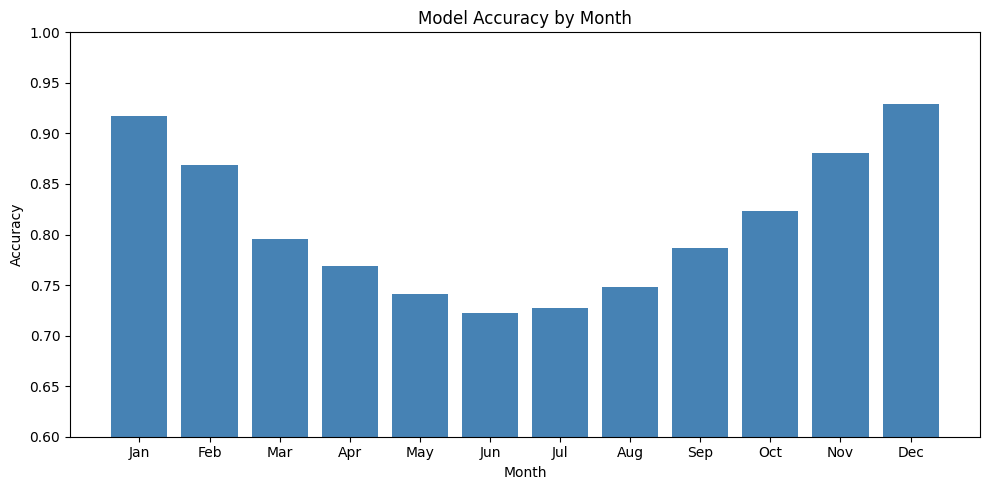

In [60]:
X_test_analysis = X_test.copy()
X_test_analysis['actual'] = y_test.values
X_test_analysis['predicted'] = y_pred_no_mag
X_test_analysis['month_num'] = X_test_analysis['MONTH_NAME']

monthly = X_test_analysis.groupby('month_num').apply(
    lambda x: (x['actual'] == x['predicted']).mean()
).reset_index()
monthly.columns = ['Code', 'Accuracy']

# Map codes back to month names and chronological order
code_to_month = {0:'Apr', 1:'Aug', 2:'Dec', 3:'Feb', 4:'Jan', 
                 5:'Jul', 6:'Jun', 7:'Mar', 8:'May', 9:'Nov', 10:'Oct', 11:'Sep'}
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

monthly['MonthName'] = monthly['Code'].map(code_to_month)
monthly['MonthOrder'] = monthly['MonthName'].map({m:i for i,m in enumerate(month_order)})
monthly = monthly.sort_values('MonthOrder').reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.bar(range(len(monthly)), monthly['Accuracy'], color='steelblue')
plt.xticks(range(len(monthly)), monthly['MonthName'])
plt.ylim(0.6, 1.0)
plt.title('Model Accuracy by Month')
plt.ylabel('Accuracy')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig('monthly_accuracy.png', dpi=150)
plt.show()

In [61]:
# Accuracy by state
state_accuracy = X_test_analysis.groupby('STATE').apply(
    lambda x: (x['actual'] == x['predicted']).mean()
).reset_index()
state_accuracy.columns = ['STATE', 'Accuracy']
state_accuracy = state_accuracy.sort_values('Accuracy', ascending=False)

print("Top 10 states (highest accuracy):")
print(state_accuracy.head(10).to_string(index=False))
print("\nBottom 10 states (lowest accuracy):")
print(state_accuracy.tail(10).to_string(index=False))

Top 10 states (highest accuracy):
 STATE  Accuracy
     1       1.0
    26       1.0
     2       1.0
     6       1.0
     5       1.0
    16       1.0
    15       1.0
    29       1.0
    25       1.0
    28       1.0

Bottom 10 states (lowest accuracy):
 STATE  Accuracy
    61  0.750000
     9  0.743590
    40  0.740150
    48  0.738333
    49  0.736639
    23  0.735969
    55  0.729763
    38  0.725561
    21  0.708333
    12  0.000000


In [62]:
# Decode state codes back to names
state_decoder = dict(enumerate(balanced_df['STATE'].astype('category').cat.categories))
X_test_analysis['state_name'] = X_test_analysis['STATE'].map(state_decoder)

state_accuracy = X_test_analysis.groupby('state_name').apply(
    lambda x: (x['actual'] == x['predicted']).mean()
).reset_index()
state_accuracy.columns = ['State', 'Accuracy']

# Add record count so we can spot states with too few records
state_counts = X_test_analysis.groupby('state_name').size().reset_index()
state_counts.columns = ['State', 'Count']
state_accuracy = state_accuracy.merge(state_counts, on='State')
state_accuracy = state_accuracy.sort_values('Accuracy', ascending=False)

print("Top 10 states (highest accuracy):")
print(state_accuracy.head(10).to_string(index=False))
print("\nBottom 10 states (lowest accuracy):")
print(state_accuracy.tail(10).to_string(index=False))

Top 10 states (highest accuracy):
         State  Accuracy  Count
        ALASKA       1.0     71
    LAKE HURON       1.0      9
AMERICAN SAMOA       1.0      1
ATLANTIC SOUTH       1.0     59
ATLANTIC NORTH       1.0     90
GULF OF MEXICO       1.0    119
          GUAM       1.0      6
 LAKE ST CLAIR       1.0      1
     LAKE ERIE       1.0     21
  LAKE ONTARIO       1.0      1

Bottom 10 states (lowest accuracy):
         State  Accuracy  Count
VIRGIN ISLANDS  0.750000      4
   CONNECTICUT  0.743590     78
      NEBRASKA  0.740150   1066
          OHIO  0.738333    600
      OKLAHOMA  0.736639   1553
        KANSAS  0.735969   1568
  SOUTH DAKOTA  0.729763    803
      MISSOURI  0.725561   1115
       INDIANA  0.708333    672
     E PACIFIC  0.000000      1


In [63]:
# Filter to meaningful states only (at least 100 records)
real_states = state_accuracy[state_accuracy['Count'] >= 100].copy()
real_states = real_states.sort_values('Accuracy', ascending=False)

print("Top 10 states (highest accuracy, min 100 records):")
print(real_states.head(10).to_string(index=False))
print("\nBottom 10 states (lowest accuracy, min 100 records):")
print(real_states.tail(10).to_string(index=False))

Top 10 states (highest accuracy, min 100 records):
         State  Accuracy  Count
GULF OF MEXICO  1.000000    119
        HAWAII  0.981132    106
 WEST VIRGINIA  0.909910    222
        OREGON  0.892157    102
    NEW JERSEY  0.882075    212
         MAINE  0.867052    173
    CALIFORNIA  0.852459    305
 MASSACHUSETTS  0.850575    174
       WYOMING  0.838710    341
     LOUISIANA  0.827744    656

Bottom 10 states (lowest accuracy, min 100 records):
         State  Accuracy  Count
  PENNSYLVANIA  0.753065    571
SOUTH CAROLINA  0.751527    491
      MICHIGAN  0.750000    528
      NEBRASKA  0.740150   1066
          OHIO  0.738333    600
      OKLAHOMA  0.736639   1553
        KANSAS  0.735969   1568
  SOUTH DAKOTA  0.729763    803
      MISSOURI  0.725561   1115
       INDIANA  0.708333    672


In [64]:
# List of actual US states only
us_states = [
    'ALABAMA', 'ALASKA', 'ARIZONA', 'ARKANSAS', 'CALIFORNIA', 'COLORADO',
    'CONNECTICUT', 'DELAWARE', 'FLORIDA', 'GEORGIA', 'HAWAII', 'IDAHO',
    'ILLINOIS', 'INDIANA', 'IOWA', 'KANSAS', 'KENTUCKY', 'LOUISIANA',
    'MAINE', 'MARYLAND', 'MASSACHUSETTS', 'MICHIGAN', 'MINNESOTA',
    'MISSISSIPPI', 'MISSOURI', 'MONTANA', 'NEBRASKA', 'NEVADA',
    'NEW HAMPSHIRE', 'NEW JERSEY', 'NEW MEXICO', 'NEW YORK',
    'NORTH CAROLINA', 'NORTH DAKOTA', 'OHIO', 'OKLAHOMA', 'OREGON',
    'PENNSYLVANIA', 'RHODE ISLAND', 'SOUTH CAROLINA', 'SOUTH DAKOTA',
    'TENNESSEE', 'TEXAS', 'UTAH', 'VERMONT', 'VIRGINIA', 'WASHINGTON',
    'WEST VIRGINIA', 'WISCONSIN', 'WYOMING'
]

real_states = state_accuracy[
    (state_accuracy['State'].isin(us_states)) & 
    (state_accuracy['Count'] >= 100)
].sort_values('Accuracy', ascending=False)

print("Top 10 states (highest accuracy):")
print(real_states.head(10).to_string(index=False))
print("\nBottom 10 states (lowest accuracy):")
print(real_states.tail(10).to_string(index=False))

Top 10 states (highest accuracy):
        State  Accuracy  Count
       HAWAII  0.981132    106
WEST VIRGINIA  0.909910    222
       OREGON  0.892157    102
   NEW JERSEY  0.882075    212
        MAINE  0.867052    173
   CALIFORNIA  0.852459    305
MASSACHUSETTS  0.850575    174
      WYOMING  0.838710    341
    LOUISIANA  0.827744    656
     VIRGINIA  0.821018    609

Bottom 10 states (lowest accuracy):
         State  Accuracy  Count
  PENNSYLVANIA  0.753065    571
SOUTH CAROLINA  0.751527    491
      MICHIGAN  0.750000    528
      NEBRASKA  0.740150   1066
          OHIO  0.738333    600
      OKLAHOMA  0.736639   1553
        KANSAS  0.735969   1568
  SOUTH DAKOTA  0.729763    803
      MISSOURI  0.725561   1115
       INDIANA  0.708333    672


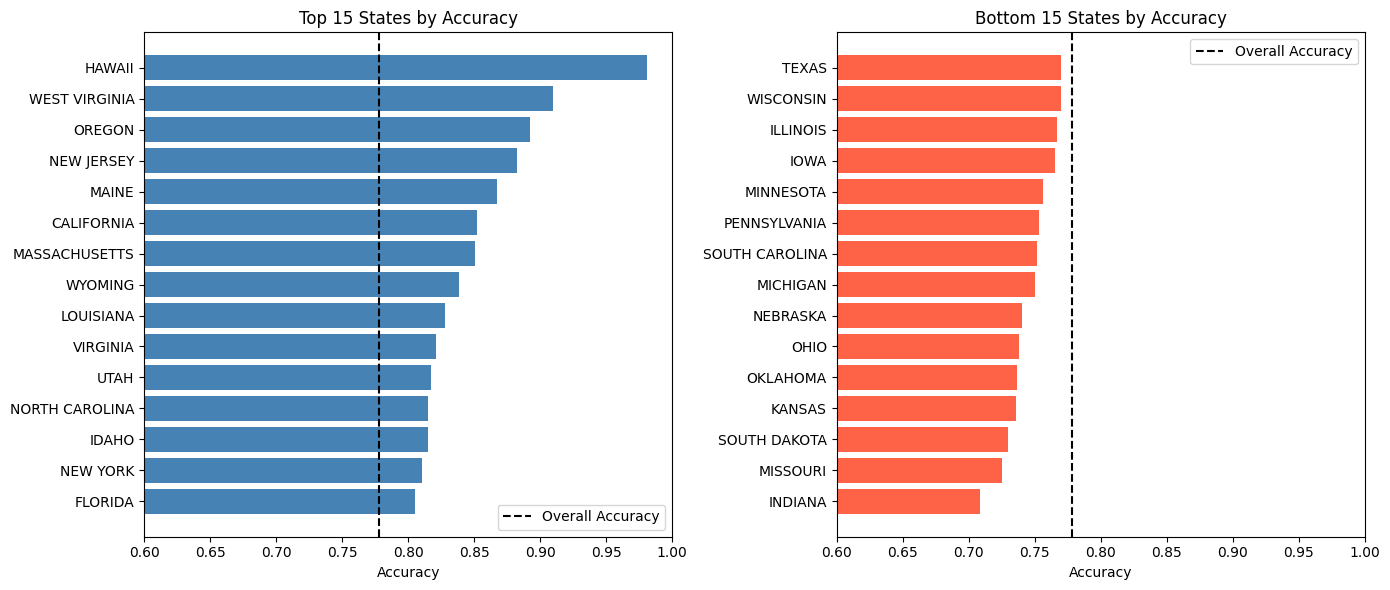

In [65]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

top15 = real_states.head(15).sort_values('Accuracy')
bottom15 = real_states.tail(15).sort_values('Accuracy')

ax1.barh(top15['State'], top15['Accuracy'], color='steelblue')
ax1.axvline(x=0.7782, color='black', linestyle='--', label='Overall Accuracy')
ax1.set_xlabel('Accuracy')
ax1.set_title('Top 15 States by Accuracy')
ax1.set_xlim(0.6, 1.0)
ax1.legend()

ax2.barh(bottom15['State'], bottom15['Accuracy'], color='tomato')
ax2.axvline(x=0.7782, color='black', linestyle='--', label='Overall Accuracy')
ax2.set_xlabel('Accuracy')
ax2.set_title('Bottom 15 States by Accuracy')
ax2.set_xlim(0.6, 1.0)
ax2.legend()

plt.tight_layout()
plt.savefig('state_accuracy.png', dpi=150)
plt.show()

## 11. Geographic Misclassification Map

An interactive map showing where the model makes mistakes geographically. Red dots represent misclassified events — weather records that the model incorrectly classified as tornado or non-tornado. The geographic distribution of errors reveals which regions are hardest for the model to classify correctly.

In [66]:
import plotly.express as px

# Get misclassified points
misclassified = X_test_analysis[X_test_analysis['actual'] != X_test_analysis['predicted']].copy()
correct = X_test_analysis[X_test_analysis['actual'] == X_test_analysis['predicted']].copy()

# Sample to keep it manageable
misclassified_sample = misclassified.sample(n=min(2000, len(misclassified)), random_state=42)
correct_sample = correct.sample(n=2000, random_state=42)

fig = px.scatter_geo(
    misclassified_sample,
    lat='BEGIN_LAT',
    lon='BEGIN_LON',
    scope='usa',
    title='Geographic Distribution of Misclassified Events',
    color_discrete_sequence=['red'],
    opacity=0.4
)

fig.update_layout(title_font_size=16)
fig.write_html('misclassification_map.html')
fig.show()

In [67]:
misclassified_sample['type'] = 'Misclassified'
correct_sample['type'] = 'Correct'
combined = pd.concat([misclassified_sample, correct_sample])

fig2 = px.scatter_geo(
    combined,
    lat='BEGIN_LAT',
    lon='BEGIN_LON',
    color='type',
    scope='usa',
    title='Correct vs Misclassified Predictions by Location',
    color_discrete_map={'Correct': 'steelblue', 'Misclassified': 'red'},
    opacity=0.4
)

fig2.update_geos(
    showsubunits=True,
    subunitcolor='black',
    subunitwidth=1.5,
    showlakes=False
)

fig2.update_layout(title_font_size=16)
fig2.write_html('prediction_map.html')
fig2.show()

## 12. Interactive Prediction Demo

A simple demonstration of the trained model in action. Given a set of user-provided inputs — month, day, time, location, and reported injuries/deaths — the model outputs a binary prediction (tornado or no tornado) along with a confidence percentage. This illustrates how the model could be applied to classify a new weather event in real time.

In [68]:
def predict_tornado():
    print("=== Tornado Prediction Demo ===\n")
    
    months = {'January':0,'February':1,'March':2,'April':3,'May':4,'June':5,
              'July':6,'August':7,'September':8,'October':9,'November':10,'December':11}
    
    print("Enter the following information:")
    month = input("Month (e.g. May): ").strip().title()
    month_code = months.get(month, 4)
    
    day = int(input("Day of month (1-31): "))
    time = int(input("Time (military, e.g. 1430 for 2:30pm): "))
    lat = float(input("Latitude (e.g. 35.5 for Oklahoma): "))
    lon = float(input("Longitude (e.g. -97.5 for Oklahoma): "))
    injuries = int(input("Direct injuries reported: "))
    deaths = int(input("Direct deaths reported: "))
    
    input_df = pd.DataFrame([[month_code, day, time, 25, lat, lon, injuries, deaths]],
                             columns=['MONTH_NAME','BEGIN_DAY','BEGIN_TIME','STATE',
                                      'BEGIN_LAT','BEGIN_LON','INJURIES_DIRECT','DEATHS_DIRECT'])
    
    prediction = model_no_mag.predict(input_df)[0]
    probability = model_no_mag.predict_proba(input_df)[0]
    
    print(f"\n=== Result ===")
    print(f"Prediction: {'🌪️ TORNADO' if prediction == 1 else '✅ NO TORNADO'}")
    print(f"Confidence: {max(probability)*100:.1f}%")
    print(f"Tornado probability:    {probability[1]*100:.1f}%")
    print(f"No tornado probability: {probability[0]*100:.1f}%")

predict_tornado()

=== Tornado Prediction Demo ===

Enter the following information:

=== Result ===
Prediction: 🌪️ TORNADO
Confidence: 66.6%
Tornado probability:    66.6%
No tornado probability: 33.4%


## 13. Historical Tornado Frequency Trend

Tornado records in the NOAA database show an upward trend from 1950 to present. This does not necessarily mean more tornadoes are occurring — it primarily reflects improvements in detection and reporting over time. Doppler radar wasn't widely deployed until the 1990s, and the network of trained storm spotters has grown significantly over decades. The spike around 2011 corresponds to one of the most active tornado seasons on record, including the devastating April 27 Super Outbreak.

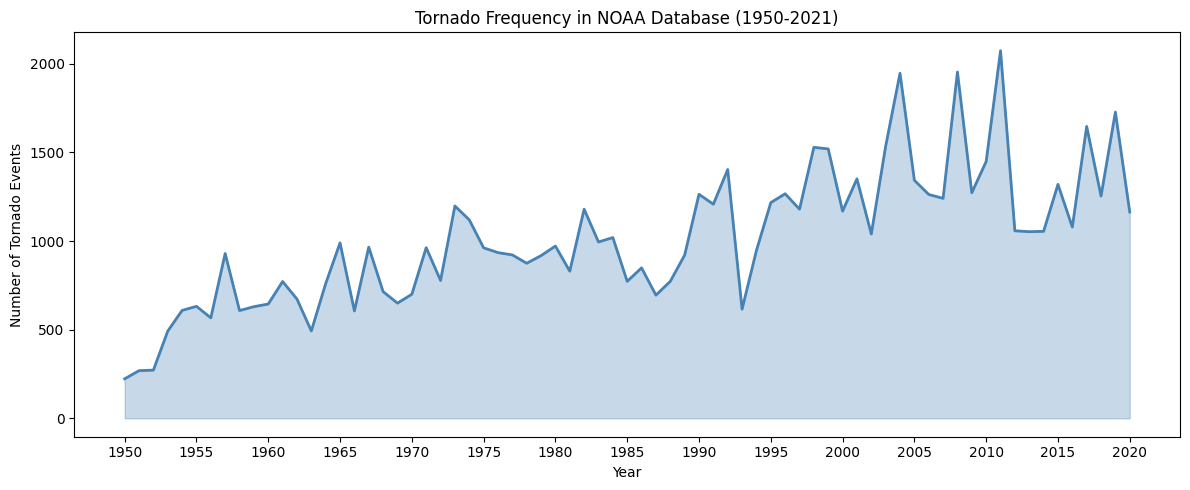

In [69]:
# Year-over-year tornado frequency using YEAR column directly
tornado_by_year = df[df['tornado'] == 1].copy()

yearly_counts = tornado_by_year.groupby('YEAR').size().reset_index()
yearly_counts.columns = ['Year', 'Count']

plt.figure(figsize=(12, 5))
plt.plot(yearly_counts['Year'], yearly_counts['Count'], color='steelblue', linewidth=2)
plt.fill_between(yearly_counts['Year'], yearly_counts['Count'], alpha=0.3, color='steelblue')
plt.title('Tornado Frequency in NOAA Database (1950-2021)')
plt.xlabel('Year')
plt.ylabel('Number of Tornado Events')
plt.xticks(range(1950, 2025, 5))
plt.tight_layout()
plt.savefig('tornado_trend.png', dpi=150)
plt.show()

## 14. Prediction Confidence Distribution

This histogram shows the distribution of predicted tornado probabilities across all 28,812 test records. The large spike near 0.0 indicates the model is very confident about ruling out tornadoes for many events — these are likely clear-cut cases like winter storms, droughts, and floods that look nothing like tornado conditions. The broader hump on the right (0.6–0.8) represents tornado predictions made with moderate confidence. The model is generally more confident ruling out tornadoes than confirming them, which reflects the inherent difficulty of tornado identification.

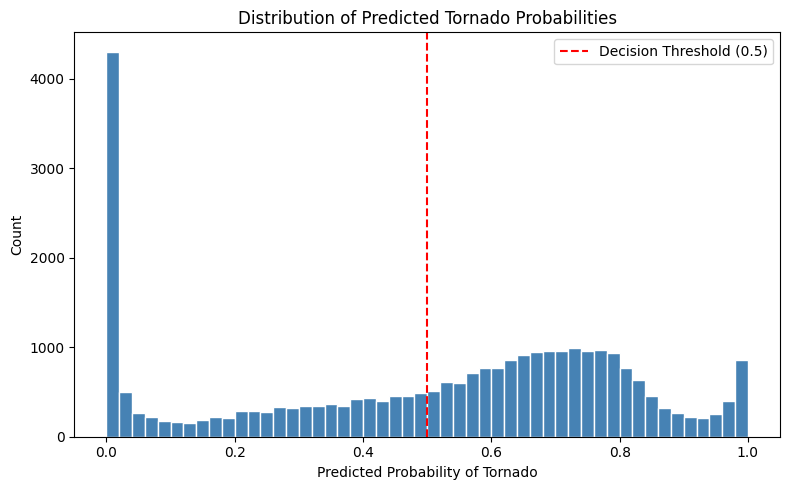

In [70]:
y_prob_all = model_no_mag.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8, 5))
plt.hist(y_prob_all, bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
plt.title('Distribution of Predicted Tornado Probabilities')
plt.xlabel('Predicted Probability of Tornado')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('probability_distribution.png', dpi=150)
plt.show()

## 15. Misclassification Analysis by EF Scale

This analysis examines which tornado intensities the model struggles with most. The EF (Enhanced Fujita) scale rates tornado intensity from EF0 (weakest) to EF5 (most violent). Note that older records (pre-2007) use the original Fujita scale (F0-F5) while newer records use the EF scale — both are present in this dataset since it spans 1950-2021.

In [71]:
# Get misclassified tornado records and merge with original EF scale data
misclassified_tornados = X_test_analysis[
    (X_test_analysis['actual'] == 1) & 
    (X_test_analysis['predicted'] == 0)
].copy()

correct_tornados = X_test_analysis[
    (X_test_analysis['actual'] == 1) & 
    (X_test_analysis['predicted'] == 1)
].copy()

# Merge with original df to get TOR_F_SCALE
misclassified_tornados['TOR_F_SCALE'] = balanced_df.loc[misclassified_tornados.index, 'TOR_F_SCALE'].values
correct_tornados['TOR_F_SCALE'] = balanced_df.loc[correct_tornados.index, 'TOR_F_SCALE'].values

# Count by EF scale
miss_counts = misclassified_tornados['TOR_F_SCALE'].value_counts().sort_index()
correct_counts = correct_tornados['TOR_F_SCALE'].value_counts().sort_index()

print("Misclassified tornado EF distribution:")
print(miss_counts)
print("\nCorrectly classified tornado EF distribution:")
print(correct_counts)

Misclassified tornado EF distribution:
TOR_F_SCALE
EF0    232
EF1    175
EF2     19
EF3      4
EFU      2
F0     620
F1     573
F2     223
F3      31
F4       1
Name: count, dtype: int64

Correctly classified tornado EF distribution:
TOR_F_SCALE
EF0    1747
EF1    1124
EF2     337
EF3      96
EF4      23
EF5       5
EFU      78
F0     3531
F1     2821
F2     1561
F3      562
F4      209
F5       23
Name: count, dtype: int64


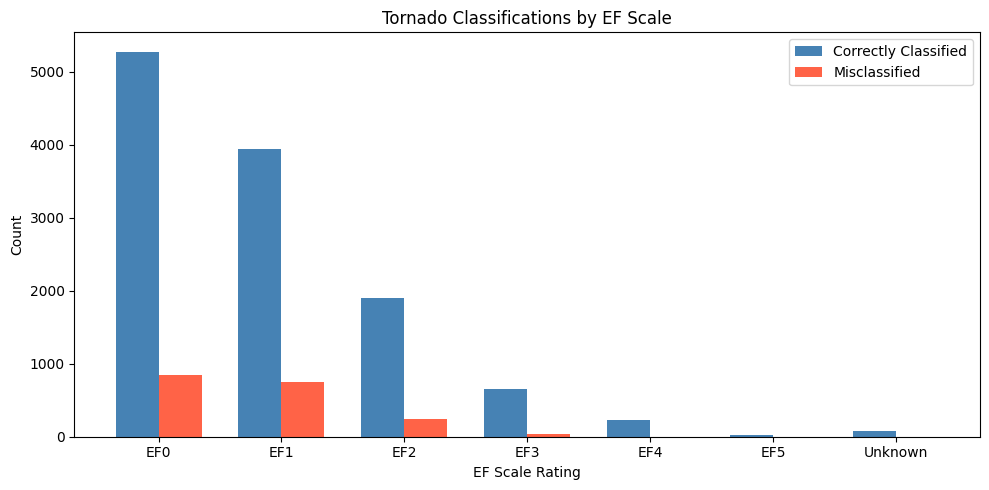

In [72]:
# Combine F and EF scales for cleaner visualization
scale_map = {'F0':'0', 'EF0':'0', 'F1':'1', 'EF1':'1', 'F2':'2', 'EF2':'2',
             'F3':'3', 'EF3':'3', 'F4':'4', 'EF4':'4', 'F5':'5', 'EF5':'5', 'EFU':'Unknown'}

misclassified_tornados['scale'] = misclassified_tornados['TOR_F_SCALE'].map(scale_map)
correct_tornados['scale'] = correct_tornados['TOR_F_SCALE'].map(scale_map)

miss_combined = misclassified_tornados['scale'].value_counts().sort_index()
correct_combined = correct_tornados['scale'].value_counts().sort_index()

categories = ['0', '1', '2', '3', '4', '5', 'Unknown']
miss_vals = [miss_combined.get(c, 0) for c in categories]
correct_vals = [correct_combined.get(c, 0) for c in categories]

x = range(len(categories))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar([i - width/2 for i in x], correct_vals, width, label='Correctly Classified', color='steelblue')
plt.bar([i + width/2 for i in x], miss_vals, width, label='Misclassified', color='tomato')
plt.xticks(x, [f'EF{c}' if c != 'Unknown' else 'Unknown' for c in categories])
plt.title('Tornado Classifications by EF Scale')
plt.ylabel('Count')
plt.xlabel('EF Scale Rating')
plt.legend()
plt.tight_layout()
plt.savefig('ef_scale_distribution.png', dpi=150)
plt.show()

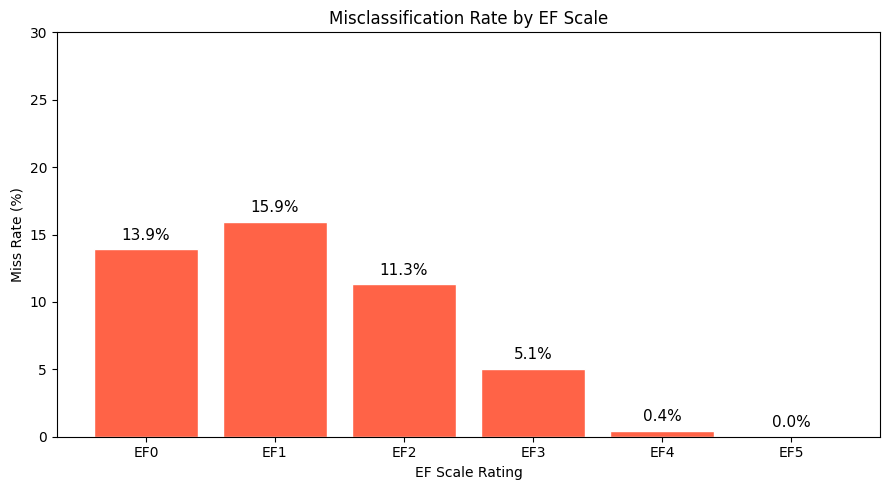

In [73]:
# Calculate miss rate by EF scale
categories = ['0', '1', '2', '3', '4', '5']
miss_vals = [miss_combined.get(c, 0) for c in categories]
correct_vals = [correct_combined.get(c, 0) for c in categories]
total_vals = [m + c for m, c in zip(miss_vals, correct_vals)]
miss_rate = [m/t*100 if t > 0 else 0 for m, t in zip(miss_vals, total_vals)]

plt.figure(figsize=(9, 5))
bars = plt.bar([f'EF{c}' for c in categories], miss_rate, color='tomato', edgecolor='white')
plt.title('Misclassification Rate by EF Scale')
plt.xlabel('EF Scale Rating')
plt.ylabel('Miss Rate (%)')
plt.ylim(0, 30)

# Add percentage labels on top of each bar
for bar, rate in zip(bars, miss_rate):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{rate:.1f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('ef_miss_rate.png', dpi=150)
plt.show()

## 16. Final Summary

A consolidated summary of the final model's configuration and performance across all evaluation metrics.

In [74]:
print("=== Final Model Performance Summary ===")
print(f"Algorithm:      Random Forest Classifier")
print(f"Dataset:        NOAA Storm Events Database (1950-2021)")
print(f"Total Records:  {len(balanced_df):,} (balanced)")
print(f"Features:       {len(features)}")
print(f"Trees:          {model_no_mag.n_estimators}")
print(f"Max Depth:      {model_no_mag.max_depth}")
print(f"Train size:     {X_train.shape[0]:,}")
print(f"Test size:      {X_test.shape[0]:,}")
print()
print("--- Evaluation Metrics ---")
print(f"Accuracy:       {accuracy_score(y_test, y_pred_no_mag):.4f}")
print(f"Precision:      {precision_score(y_test, y_pred_no_mag):.4f}")
print(f"Recall:         {recall_score(y_test, y_pred_no_mag):.4f}")
print(f"F1-Score:       {f1_score(y_test, y_pred_no_mag):.4f}")
print(f"AUC:            {roc_auc:.4f}")
print(f"CV Mean F1:     {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print()
print("--- Comparison ---")
print(f"Random Forest F1:      {f1_score(y_test, y_pred_no_mag):.4f}")
print(f"Gradient Boosting F1:  {f1_score(y_test, y_pred_gb):.4f}")

=== Final Model Performance Summary ===
Algorithm:      Random Forest Classifier
Dataset:        NOAA Storm Events Database (1950-2021)
Total Records:  144,060 (balanced)
Features:       8
Trees:          200
Max Depth:      20
Train size:     115,248
Test size:      28,812

--- Evaluation Metrics ---
Accuracy:       0.7782
Precision:      0.7378
Recall:         0.8633
F1-Score:       0.7956
AUC:            0.8664
CV Mean F1:     0.7438 (+/- 0.0142)

--- Comparison ---
Random Forest F1:      0.7956
Gradient Boosting F1:  0.7750


## 17. Conclusions and Limitations

### Conclusions
This project successfully built a Random Forest classifier capable of distinguishing tornado events from other severe weather events with **77.82% accuracy and 86.33% recall** using only 8 geographic and temporal features. Key findings include:

- Geographic location (latitude and longitude) is the strongest predictor, reflecting the well-known concentration of tornadoes in Tornado Alley
- The model performs best in winter months and worst during peak tornado season (June/July), when severe weather conditions are most ambiguous
- Tornado Alley states (Kansas, Oklahoma, Missouri, Indiana) have the lowest accuracy — the hardest region to classify
- The model almost never misses violent tornadoes — EF4 miss rate is 0.4% and EF5 miss rate is 0.0%
- Random Forest outperformed Gradient Boosting on 3 of 4 metrics, validating the original algorithm choice

### Limitations
- **No atmospheric features** — the dataset does not include pre-storm atmospheric readings such as pressure, wind shear, humidity, or CAPE, which are the primary indicators used by meteorologists
- **Classification, not prediction** — the model classifies historical recorded events rather than forecasting future tornado occurrence
- **Geographic proxy only** — the model learns where tornadoes tend to occur rather than the physical conditions that cause them
- **Dataset coverage** — before 1996, NOAA only recorded tornadoes, hail, and thunderstorm winds, meaning earlier decades have less diverse non-tornado examples

### Future Improvements
- Incorporate atmospheric reanalysis data (e.g., ERA5) to add pressure, wind shear, and humidity features
- Train on pre-storm atmospheric conditions to enable true predictive capability
- Explore deep learning approaches such as CNNs applied to radar imagery (e.g., the TorNet dataset from MIT)